<a href="https://colab.research.google.com/github/JyRaGa/CS303-Machine-Learning_Coursework/blob/main/exp2_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS303 Machine Learning Lab
## Experiment 2: Problem Formulation, Dataset Inspection and Baseline Modelling
### (24/CS/232)

**1. Problem Formulation & Naive Prediction**

* **Problem Type:** The objective is to predict whether an individual makes more than 50K a year. Because the target variable (`income`) consists of discrete categories (<=50K or >50K), this is a classification problem.
* **Naive Prediction:** A trivial baseline model that simply predicts the most frequent income bracket for every instance will achieve an accuracy strictly reflecting the class imbalance of the dataset.

**2. Loading the Dataset**

In [1]:
# importing pandas for data manipulation
import pandas as pd
# importing numpy for math operations
import numpy as np
# importing matplotlib for plotting graphs
import matplotlib.pyplot as plt
# importing seaborn for visualizations
import seaborn as sns
url = 'https://raw.githubusercontent.com/JyRaGa/CS303-Machine-Learning_Coursework/refs/heads/main/datasets/adult.csv'
# reading the csv file into a dataframe
df = pd.read_csv(url)

# printing the number of rows and columns
print("dataset shape:", df.shape)

# displaying the first 2 rows to understand the structure
df.head(2)

dataset shape: (152, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K


In [2]:
# getting the info about data types and non-null counts
print("dataset information:")
df.info()

# printing statistical summary of numerical columns
print("\nstatistical summary:")
df.describe()

dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             152 non-null    int64 
 1   workclass       152 non-null    object
 2   fnlwgt          152 non-null    int64 
 3   education       152 non-null    object
 4   education-num   152 non-null    int64 
 5   marital-status  152 non-null    object
 6   occupation      152 non-null    object
 7   relationship    152 non-null    object
 8   race            152 non-null    object
 9   gender          152 non-null    object
 10  capital-gain    152 non-null    int64 
 11  capital-loss    152 non-null    int64 
 12  hours-per-week  152 non-null    int64 
 13  native-country  152 non-null    object
 14  income          152 non-null    object
dtypes: int64(6), object(9)
memory usage: 17.9+ KB

statistical summary:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,152.000000,152.000000,152.000000,152.000000,152.0,152.000000
mean,36.381579,194433.750000,12.151316,445.703947,0.0,41.539474
std,9.044360,64701.829699,2.280815,2378.504956,0.0,7.750139
min,19.000000,19345.000000,4.000000,0.000000,0.0,13.000000
25%,30.000000,164526.000000,10.000000,0.000000,0.0,40.000000
50%,34.500000,190524.000000,13.000000,0.000000,0.0,40.000000
75%,42.250000,210198.000000,13.000000,0.000000,0.0,40.000000
max,59.000000,401851.000000,16.000000,15024.000000,0.0,80.000000


**3. Dataset Health Checks**

In [3]:
# replacing '?' with standard nans since the adult dataset uses '?' for missing data
df = df.replace('?', np.nan)

# checking the total number of duplicate rows
print("duplicate rows:", df.duplicated().sum())

# checking the total count of missing values per column
print("\nmissing values:\n", df.isnull().sum())

# finding all columns that have object/string data types
print("\ncategorical columns:", df.select_dtypes(include=['object']).columns.tolist())

# counting unique values in each column
print("\nunique values per column:\n", df.nunique())

# checking for constant columns (columns with only 1 unique value)
print("\nconstant columns:", [col for col in df.columns if df[col].nunique() <= 1])

# verifying if there are any impossible negative values in numerical metrics
print("\nchecking for impossible values:")
print("negative ages:", (df['age'] < 0).sum())
print("negative hours-per-week:", (df['hours-per-week'] < 0).sum())

duplicate rows: 0

missing values:
 age               0
workclass         2
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        2
relationship      0
race              0
gender            0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    2
income            0
dtype: int64

categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']

unique values per column:
 age               38
workclass          6
fnlwgt            78
education         11
education-num     11
marital-status     5
occupation        11
relationship       5
race               3
gender             2
capital-gain       6
capital-loss       1
hours-per-week    10
native-country     6
income             2
dtype: int64

constant columns: ['capital-loss']

checking for impossible values:
negative ages: 0
negative hours-per-week: 0


**4. Data Preprocessing**

The data is cleaned prior to modeling. Duplicates are dropped, missing values are imputed, and categorical variables are mapped to a numerical format.

In [4]:
# dropping duplicate rows
df = df.drop_duplicates()

# filling missing values (median for numerical, mode for categorical)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(exclude=['object']).columns:
    df[col] = df[col].fillna(df[col].median())

# encoding the target variable (income >50k becomes 1, else 0)
df['income'] = df['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# converting all other categorical columns to dummy variables
cat_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# checking the cleaned dataframe
df.head(3)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,relationship_Unmarried,relationship_Wife,race_Black,race_White,gender_Male,native-country_India,native-country_Jamaica,native-country_Mexico,native-country_South,native-country_United-States
0,39,77516,13,2174,0,40,0,False,False,False,...,False,False,False,True,True,False,False,False,False,True
1,50,83311,13,0,0,13,0,False,False,False,...,False,False,False,True,True,False,False,False,False,True
2,38,215646,9,0,0,40,0,False,True,False,...,False,False,False,True,True,False,False,False,False,True


**5. Splitting Data into Features and Target**

In [5]:
# importing train_test_split function
from sklearn.model_selection import train_test_split

# separating the input features (X) by dropping the target column
X = df.drop('income', axis=1)
# isolating the target variable (y)
y = df['income']

# splitting the data into 70% training and 30% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

**6. Dummy Baseline Models**

In [6]:
# importing dummy classifier to set up baselines
from sklearn.dummy import DummyClassifier
# importing accuracy score metric
from sklearn.metrics import accuracy_score

# strategy 1: creating a baseline that always predicts the most frequent class
dummy_freq = DummyClassifier(strategy='most_frequent')
# fitting the most frequent baseline on training data
dummy_freq.fit(X_train, y_train)
# calculating accuracy for most frequent baseline
acc_freq = accuracy_score(y_test, dummy_freq.predict(X_test))
# printing the result
print("most frequent baseline accuracy:", round(acc_freq, 4))

# strategy 2: creating a stratified baseline that predicts randomly based on class distribution
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
# fitting the stratified baseline
dummy_strat.fit(X_train, y_train)
# calculating accuracy for stratified baseline
acc_strat = accuracy_score(y_test, dummy_strat.predict(X_test))
# printing the result
print("stratified baseline accuracy:", round(acc_strat, 4))

most frequent baseline accuracy: 0.5217
stratified baseline accuracy: 0.3696


**7. Training Real ML Models (Log Reg & SVM)**

Machine learning algorithms are trained and evaluated to determine if they provide a significant improvement over the dummy baselines.

In [7]:
# importing the two models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# importing all the required evaluation metrics
from sklearn.metrics import precision_score, recall_score, f1_score, log_loss, roc_auc_score, confusion_matrix, roc_curve
# hiding warnings to keep the notebook clean
import warnings
warnings.filterwarnings('ignore')

# setting up and training the logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# getting predictions and probabilities for test data
y_pred_log = log_reg.predict(X_test)
y_pred_prob_log = log_reg.predict_proba(X_test)[:, 1]

# calculating log reg accuracy
acc_log = accuracy_score(y_test, y_pred_log)

# printing log reg metrics
print("logistic regression metrics:")
print("accuracy:", round(acc_log, 4))
print("precision:", round(precision_score(y_test, y_pred_log, zero_division=0), 4))
print("recall:", round(recall_score(y_test, y_pred_log, zero_division=0), 4))
print("f1 score:", round(f1_score(y_test, y_pred_log, zero_division=0), 4))
print("log loss:", round(log_loss(y_test, y_pred_prob_log), 4))
print("roc auc:", round(roc_auc_score(y_test, y_pred_prob_log), 4))
print("\n")

# setting up and training the svm model
# setting probability to true so we can calculate log loss and roc auc
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# getting svm predictions and probabilities
y_pred_svm = svm_model.predict(X_test)
y_pred_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# calculating svm accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)

# printing svm metrics
print("support vector machine metrics:")
print("accuracy:", round(acc_svm, 4))
print("precision:", round(precision_score(y_test, y_pred_svm, zero_division=0), 4))
print("recall:", round(recall_score(y_test, y_pred_svm, zero_division=0), 4))
print("f1 score:", round(f1_score(y_test, y_pred_svm, zero_division=0), 4))
print("log loss:", round(log_loss(y_test, y_pred_prob_svm), 4))
print("roc auc:", round(roc_auc_score(y_test, y_pred_prob_svm), 4))

logistic regression metrics:
accuracy: 0.8913
precision: 0.8696
recall: 0.9091
f1 score: 0.8889
log loss: 0.3231
roc auc: 0.9337


support vector machine metrics:
accuracy: 0.6087
precision: 0.5667
recall: 0.7727
f1 score: 0.6538
log loss: 0.7131
roc auc: 0.3693


**8. Visualizing the Results**

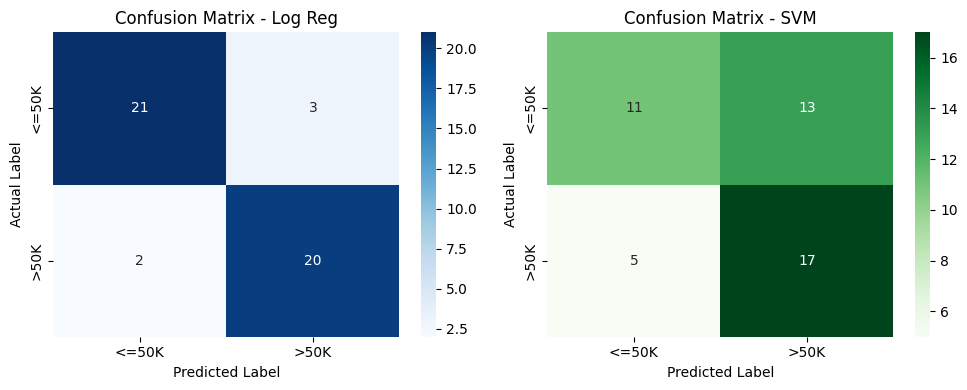

In [8]:
# setting up a 1x2 grid for the two confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# calculating the confusion matrix for logistic regression
cm_log = confusion_matrix(y_test, y_pred_log)
# plotting the log reg heatmap
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
ax[0].set_title('Confusion Matrix - Log Reg')
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# calculating the confusion matrix for svm
cm_svm = confusion_matrix(y_test, y_pred_svm)
# plotting the svm heatmap
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=ax[1], xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
ax[1].set_title('Confusion Matrix - SVM')
ax[1].set_ylabel('Actual Label')
ax[1].set_xlabel('Predicted Label')

# adjusting layout so plots do not overlap
plt.tight_layout()
# displaying the plot
plt.show()

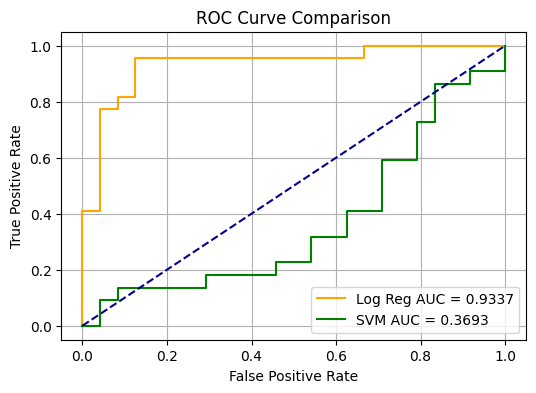

In [9]:
# calculating false positive rate, true positive rate, and auc for log reg
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_prob_log)
roc_auc_log = roc_auc_score(y_test, y_pred_prob_log)

# calculating the same metrics for svm
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_prob_svm)
roc_auc_svm = roc_auc_score(y_test, y_pred_prob_svm)

# setting up the figure
plt.figure(figsize=(6, 4))
# plotting log reg roc curve
plt.plot(fpr_log, tpr_log, color='orange', label=f'Log Reg AUC = {roc_auc_log:.4f}')
# plotting svm roc curve
plt.plot(fpr_svm, tpr_svm, color='green', label=f'SVM AUC = {roc_auc_svm:.4f}')
# plotting the random guess diagonal line
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')

# adding labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
# displaying the plot
plt.show()

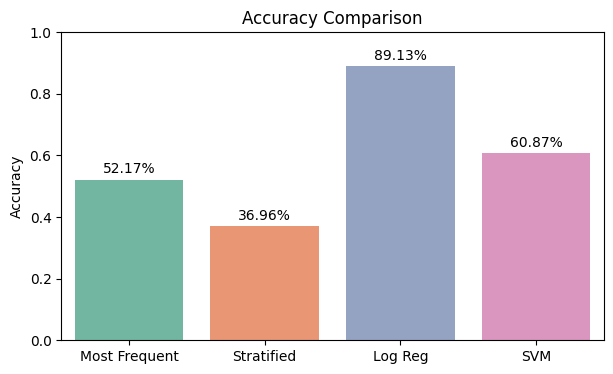

In [10]:
# creating lists of model names and their accuracies
models = ['Most Frequent', 'Stratified', 'Log Reg', 'SVM']
accuracies = [acc_freq, acc_strat, acc_log, acc_svm]

# setting up the figure size
plt.figure(figsize=(7, 4))
# plotting the bar chart
ax = sns.barplot(x=models, y=accuracies, palette='Set2')
# setting the y axis limit to 1 (100 percent)
plt.ylim(0, 1.0)
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')

# running a loop to add the percentage text on top of each bar
for i, v in enumerate(accuracies):
    ax.text(i, v + 0.02, f"{v:.2%}", ha='center')

# displaying the plot
plt.show()

**9. Observations & Conclusion**

*   **Baseline vs. ML Models:** The most-frequent baseline yielded an accuracy of 52.17%. The Logistic Regression model achieved 89.13%, confirming that the features (like education, age, and occupation) are highly predictive of income.
*   **Logistic Regression Performance:** Logistic regression performed very well. The confusion matrix shows a solid balance of true negatives and true positives. The F1 score is strong (0.8889), and the ROC curve demonstrates excellent discrimination with an AUC of 0.9337.
*   **SVM Performance:** The SVM model struggled significantly, achieving only 60.87% accuracy and a very poor AUC of 0.3693.
*   **Why did SVM fail?** The poor performance is directly linked to the lack of feature scaling. Numerical features like `fnlwgt` (which has values in the hundreds of thousands) and `capital-gain` completely dominated the distance calculations that SVM relies on to draw its decision boundary. Logistic regression is less sensitive to unscaled magnitudes. This highlights the absolute necessity of using tools like `StandardScaler` prior to training distance-based algorithms.